## **Required Libraries**

In [67]:
# Standard libraries
import os
import glob
import io
import gc
import requests

# Data manipulation
import numpy as np
import pandas as pd
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

In [68]:
# 1. Search Kaggle's input folder for your CSV file
file_path = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            file_path = os.path.join(dirname, filename)
            print(f"Found your file at: {file_path}")
            break

# 2. Load the data using the found path
if file_path:
    print("Loading data... (this might take a minute for 500MB)")
    df = pd.read_csv(file_path)
    print("Data loaded successfully! Rows:", len(df))
else:
    print("Could not find a CSV file. Double-check that the dataset is attached to this notebook.")

Found your file at: /kaggle/input/datasets/susannduta2/poverty-rate-chicago/jcxq-k9xf.csv
Found your file at: /kaggle/input/datasets/susannduta2/chicago-crime-dataset/Chicago_Crimes_2001_to_Present.csv
Loading data... (this might take a minute for 500MB)


/tmp/ipykernel_58/3568256123.py:13: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Data loaded successfully! Rows: 8596454


# **Phase 1: Longitudinal Crime Trends (2001–2025)**

To understand macro-level crime trends in Chicago, this 25-year dataset (comprising over 8.5 million records) is segmented into five distinct 5-year periods. This time-binning strategy smooths out daily or seasonal variance, highlighting structural shifts in urban crime over the quarter-century. 

The following analysis explores:
1. Volume Shifts: How overall reported crime counts have changed across different eras.
2. Categorical Trends: The trajectory of the top 5 most prevalent crime types (e.g., Theft, Battery, Criminal Damage) to determine if property and interpersonal crimes follow the same historical patterns.

## **Setup and Loading Crime Data**

In [69]:
# Load the data (with low_memory=False to fix the DtypeWarning)
file_path = '/kaggle/input/datasets/susannduta2/chicago-crime-dataset/Chicago_Crimes_2001_to_Present.csv'
print("Loading dataset...")
df = pd.read_csv(file_path, low_memory=False)

# Standardize column names to lowercase with underscores to prevent errors
df.columns = df.columns.str.lower().str.replace(' ', '_')

print(f"Data loaded successfully! Total records: {len(df)}")
display(df.head(3))

Loading dataset...
Data loaded successfully! Total records: 8596454


,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,13311263,JG503434,07/29/2022 03:39:00 AM,023XX S TROY ST,1582,OFFENSE INVOLVING CHILDREN,CHILD PORNOGRAPHY,RESIDENCE,True,False,...,25.0,30.0,17,NaN,NaN,2022,04/18/2024 03:40:59 PM,NaN,NaN,NaN
1,13053066,JG103252,01/03/2023 04:44:00 PM,039XX W WASHINGTON BLVD,2017,NARCOTICS,MANUFACTURE / DELIVER - CRACK,SIDEWALK,True,False,...,28.0,26.0,18,NaN,NaN,2023,01/20/2024 03:41:12 PM,NaN,NaN,NaN
2,12131221,JD327000,08/10/2020 09:45:00 AM,015XX N DAMEN AVE,0326,ROBBERY,AGGRAVATED VEHICULAR HIJACKING,STREET,True,False,...,1.0,24.0,03,1162795.0,1909900.0,2020,05/17/2025 03:40:52 PM,41.908418,-87.677407,"(41.908417822, -87.67740693)"


In [70]:
# Drop rows where year is missing, ensure it's an integer
df = df.dropna(subset=['year'])
df['year'] = df['year'].astype(int)

# Create 5-Year Time Bins
bins = [2000, 2005, 2010, 2015, 2020, 2026]
labels = ['2001-2005', '2006-2010', '2011-2015', '2016-2020', '2021-2025']
df['time_period'] = pd.cut(df['year'], bins=bins, labels=labels)

print("Time bins created. Here is the distribution of records per period:")
display(df['time_period'].value_counts().sort_index())

Time bins created. Here is the distribution of records per period:


time_period
2001-2005    2372051
2006-2010    2075979
2011-2015    1536866
2016-2020    1282976
2021-2025    1328582
Name: count, dtype: int64

## **Data Cleaning & Feature Engineering**

## **Aggregating Overall Volume**

This isolates the first metric for your charts: total crime volume per time period.

In [71]:
# Calculate Total Crime Volume per Period
volume_per_period = df.groupby('time_period', observed=False).size()

print("Overall Crime Volume by 5-Year Period:")
display(volume_per_period)

Overall Crime Volume by 5-Year Period:


time_period
2001-2005    2372051
2006-2010    2075979
2011-2015    1536866
2016-2020    1282976
2021-2025    1328582
dtype: int64

## **Aggregating Top 5 Crimes**

This calculates the second metric: finding the top 5 crimes and tracking them across your time periods.

In [72]:
# Isolate the Top 5 Most Common Crimes
top_5_crimes = df['primary_type'].value_counts().nlargest(5).index
print(f"The Top 5 Crimes Identified Are: {list(top_5_crimes)}")

# Group by time period and primary type
top_crimes_trend = df[df['primary_type'].isin(top_5_crimes)].groupby(
    ['time_period', 'primary_type'], observed=False
).size().unstack()

print("\nDataframe for Top 5 Crimes Trend:")
display(top_crimes_trend)

The Top 5 Crimes Identified Are: ['THEFT', 'BATTERY', 'CRIMINAL DAMAGE', 'NARCOTICS', 'ASSAULT']

Dataframe for Top 5 Crimes Trend:


primary_type,ASSAULT,BATTERY,CRIMINAL DAMAGE,NARCOTICS,THEFT
time_period,,,,,
2001-2005,148309,447104,274533,269939,477651
2006-2010,122106,370055,252095,243714,417571
2011-2015,92234,271981,160518,161279,341076
2016-2020,97341,240426,139452,61182,295166
2021-2025,119534,236449,150006,32425,294673


## **Visualizations**

/tmp/ipykernel_58/1003211947.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=volume_per_period.index, y=volume_per_period.values, ax=axes[0], palette="viridis")


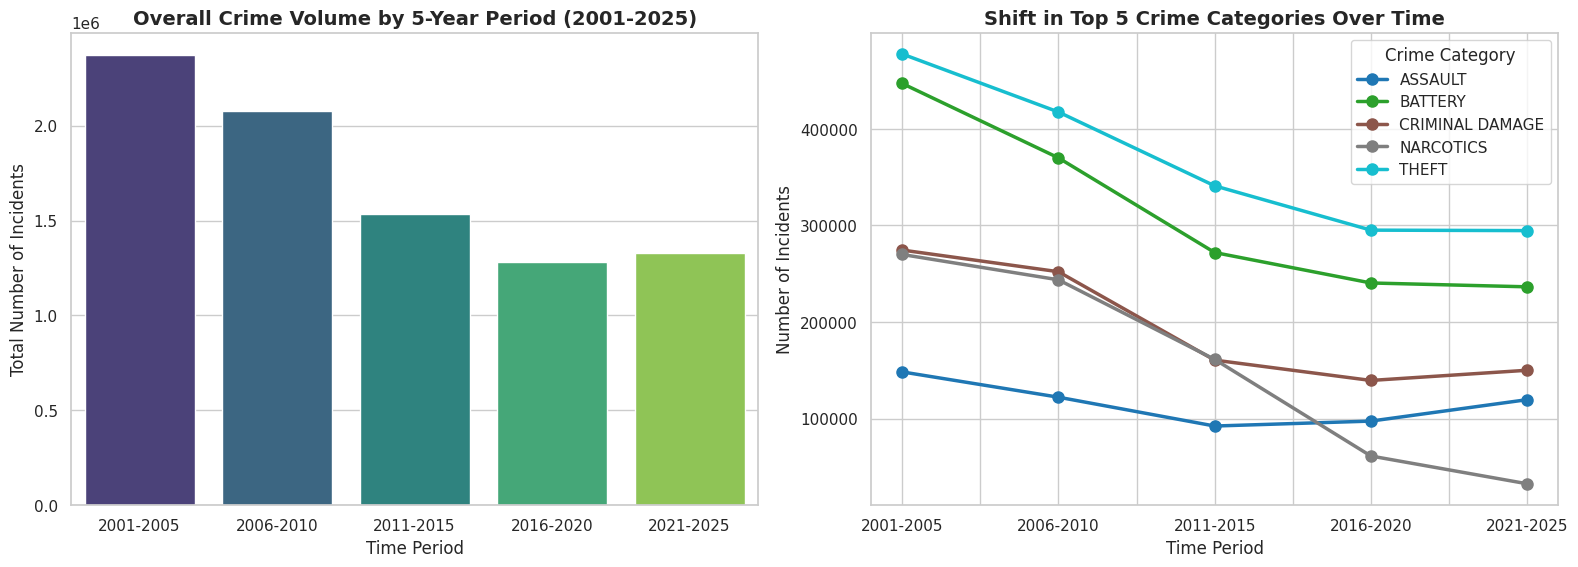

In [73]:
# Generate Visualizations
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Total Volume Bar Chart
sns.barplot(x=volume_per_period.index, y=volume_per_period.values, ax=axes[0], palette="viridis")
axes[0].set_title("Overall Crime Volume by 5-Year Period (2001-2025)", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Total Number of Incidents")
axes[0].set_xlabel("Time Period")

# Plot 2: Top 5 Crimes Trends Line Chart
top_crimes_trend.plot(kind='line', marker='o', ax=axes[1], cmap="tab10", linewidth=2.5, markersize=8)
axes[1].set_title("Shift in Top 5 Crime Categories Over Time", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Number of Incidents")
axes[1].set_xlabel("Time Period")
axes[1].legend(title="Crime Category")

plt.tight_layout()
plt.show()

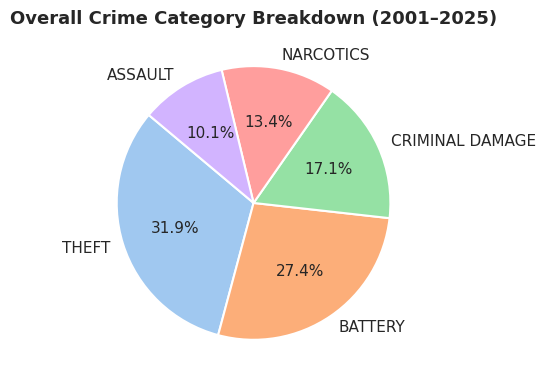

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Isolate Top 5 Crimes & Build Trend Matrix
top_5_crimes = df["primary_type"].value_counts().nlargest(5).index
top_crimes_trend = (
    df[df["primary_type"].isin(top_5_crimes)]
    .groupby(["time_period", "primary_type"], observed=False)
    .size()
    .unstack()
)

# 2. Sum overall volume across all 5-year periods
crime_totals = top_crimes_trend.sum(axis=0).sort_values(ascending=False)

# 3. Plot Pie Chart
colors = ["#A0C8F0", "#FCAE79", "#95E1A4", "#FF9E9D", "#D2B4FF"]

plt.figure(figsize=(5, 5))
plt.pie(
    crime_totals,
    labels=crime_totals.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 11},
)

plt.title(
    "Overall Crime Category Breakdown (2001–2025)",
    fontweight="bold",
    fontsize=13,
)
plt.tight_layout()
plt.show()

## **Data Cleaning for Spatial Analysis**

Dropping missing values

In [75]:
# 1. Clean the Community Area column (drop missing values and convert to integer)
df = df.dropna(subset=['community_area'])
df['community_area'] = df['community_area'].astype(int)

print("Community Area column cleaned.")
print(f"Total valid records remaining for spatial analysis: {len(df)}")

Community Area column cleaned.
Total valid records remaining for spatial analysis: 7982730


## **Aggregating the Hotspots**

calculates the total crime volume for every single neighborhood, identifies the Top 5 most dangerous areas historically, and tracks them across our time bins.

In [76]:
# 2. Identify the Top 5 Community Areas with the highest overall crime volume
top_5_areas = df['community_area'].value_counts().nlargest(5).index
print(f"The Top 5 Highest-Crime Community Area Codes are: {list(top_5_areas)}")

# 3. Create a pivot table for these hotspots across the 5-year periods
hotspot_trend = df[df['community_area'].isin(top_5_areas)].groupby(
    ['community_area', 'time_period'], observed=False
).size().unstack()

print("\nCrime Volume in Top 5 Hotspots Over Time:")
display(hotspot_trend)

The Top 5 Highest-Crime Community Area Codes are: [25, 8, 43, 28, 23]

Crime Volume in Top 5 Hotspots Over Time:


time_period,2001-2005,2006-2010,2011-2015,2016-2020,2021-2025
community_area,,,,,
8,58554,65514,50794,55976,58129
23,56328,64667,50115,38968,35721
25,110132,135074,100664,75115,67493
28,54762,55543,43506,43962,53560
43,54397,68778,52769,42241,45478


## **Visualizing Hotspot Migration (Heatmap)**

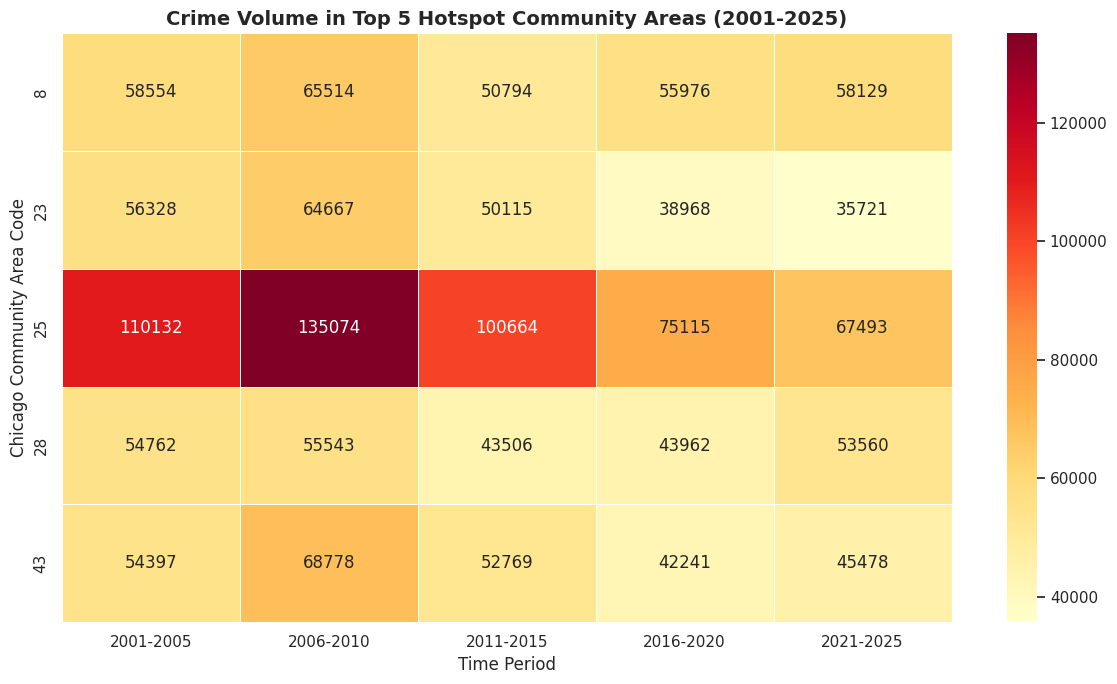

In [77]:
# 4. Generate a Heatmap for the Hotspots
plt.figure(figsize=(12, 7))

#  Yellow-Orange-Red colormap
sns.heatmap(hotspot_trend, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=.5)

plt.title("Crime Volume in Top 5 Hotspot Community Areas (2001-2025)", fontsize=14, fontweight='bold')
plt.ylabel("Chicago Community Area Code", fontsize=12)
plt.xlabel("Time Period", fontsize=12)

plt.tight_layout()
plt.show()

# **PHASE 2**

## **1.1. Merging Datasets, Crime Data and Social Economic Data**

In [78]:
# 1. FETCH THE DATA
crime_df = pd.read_csv(
    '/kaggle/input/datasets/susannduta2/chicago-crime-dataset/Chicago_Crimes_2001_to_Present.csv',
    low_memory=False
)
socio_df = pd.read_csv('/kaggle/input/datasets/susannduta2/poverty-rate-chicago/jcxq-k9xf.csv')

# Standardize all column names to be lowercase with underscores (e.g., 'Case Number' -> 'case_number')
crime_df.columns = crime_df.columns.str.strip().str.lower().str.replace(' ', '_')
socio_df.columns = socio_df.columns.str.strip().str.lower().str.replace(' ', '_')


# 2. CLEAN THE CRIME DATA dropping columns
crime_cols_to_drop = [
    'id', 'case_number', 'iucr', 'fbi_code', 'x_coordinate', 
    'y_coordinate', 'updated_on', 'block', 'beat'
]
# Added errors='ignore' so the cell won't crash if you run it twice!
crime_df_clean = crime_df.drop(columns=crime_cols_to_drop, errors='ignore')
crime_df_clean = crime_df_clean.dropna(subset=['community_area']).copy()
crime_df_clean['community_area'] = crime_df_clean['community_area'].astype(int)

# 3. CLEAN THE SOCIOECONOMIC DATA
# The socioeconomic primary key is usually 'ca' or 'community_area_number'
# rename it to 'ca' 
if 'community_area_number' in socio_df.columns:
    socio_df = socio_df.rename(columns={'community_area_number': 'ca'})
    
socio_df_clean = socio_df.dropna(subset=['ca']).copy()
socio_df_clean['ca'] = socio_df_clean['ca'].astype(int)

# 4. AGGREGATE CRIME VOLUME
crime_by_ca = crime_df_clean.groupby('community_area').agg(
    total_crimes=('primary_type', 'count')
).reset_index()

# 5. MERGE THE DATASETS
merged_df = pd.merge(crime_by_ca, socio_df_clean, left_on='community_area', right_on='ca')
merged_df = merged_df.drop('ca', axis=1)

# 6. VERIFY
print(f"Merge successful! Total Community Areas tracked: {len(merged_df)}")
display(merged_df[['community_area_name', 'total_crimes', 'hardship_index', 'per_capita_income_']].head())

Merge successful! Total Community Areas tracked: 77


,community_area_name,total_crimes,hardship_index,per_capita_income_
0,Rogers Park,124001,39.0,23939
1,West Ridge,103446,46.0,23040
2,Uptown,119252,20.0,35787
3,Lincoln Square,57824,17.0,37524
4,North Center,46758,6.0,57123


## **1.2 Boxplot of Per Capita Income & Crime**

/tmp/ipykernel_58/1807499431.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


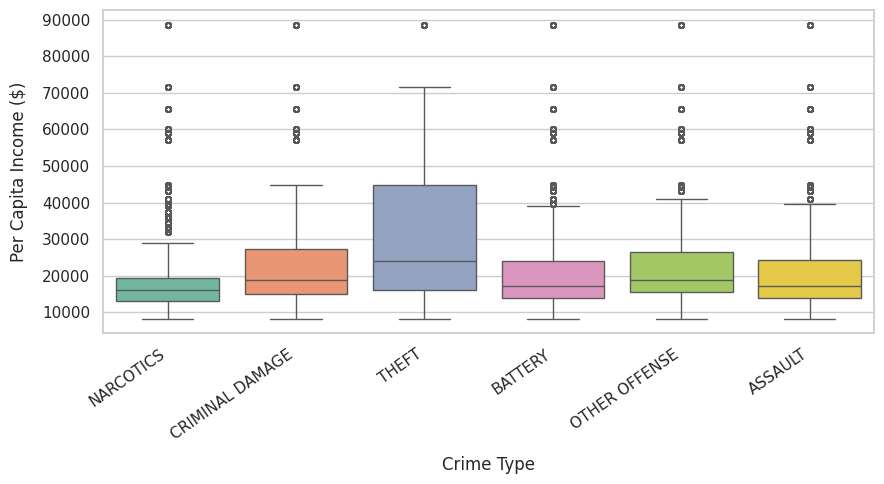

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Merge socioeconomic data 
crime_with_socio = pd.merge(
    crime_df_clean,
    socio_df_clean,
    left_on="community_area",
    right_on="ca",
    how="inner",
)

# 2. Filter for the 6 target crime categories
categories = [
    "NARCOTICS",
    "CRIMINAL DAMAGE",
    "THEFT",
    "BATTERY",
    "OTHER OFFENSE",
    "ASSAULT",
]
filtered_df = crime_with_socio[
    crime_with_socio["primary_type"].isin(categories)
]

# 3. Define column names
x_col = "primary_type"
y_col = "per_capita_income_" 

# 4. Generate the Boxplot
fig, ax = plt.subplots(figsize=(9, 5))
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=filtered_df,
    x=x_col,
    y=y_col,
    order=categories,
    palette="Set2",
    fliersize=4,
    ax=ax,
)

plt.xticks(rotation=35, ha="right")
plt.xlabel("Crime Type", labelpad=10)
plt.ylabel("Per Capita Income ($)", labelpad=10)

plt.tight_layout()
plt.show()

## **1.2. Correlation Matrix**

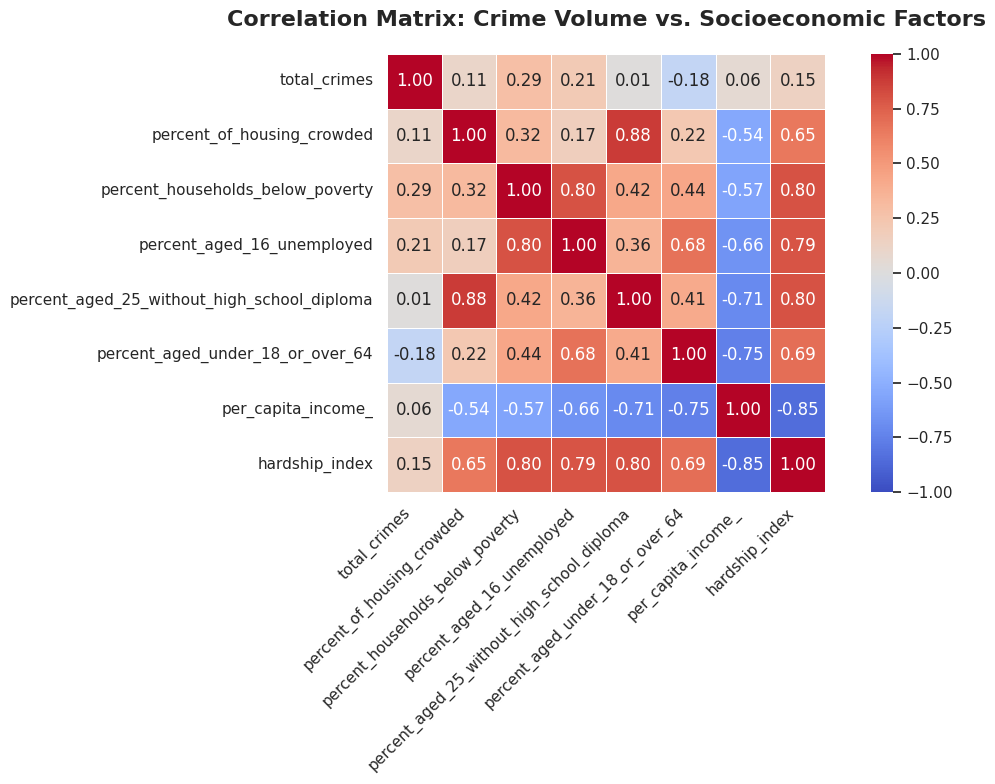

In [80]:
# 1. Select only the numeric columns for the correlation math
numeric_features = [
    'total_crimes', 'percent_of_housing_crowded', 'percent_households_below_poverty',
    'percent_aged_16_unemployed', 'percent_aged_25_without_high_school_diploma',
    'percent_aged_under_18_or_over_64', 'per_capita_income_', 'hardship_index'
]

# 2. Calculate the correlation matrix
correlation_matrix = merged_df[numeric_features].corr()

# 3. Plot the matrix as a Heatmap for easy visual analysis
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix, 
    annot=True,          # Show the actual correlation numbers
    fmt=".2f",           # Format to 2 decimal places
    cmap="coolwarm",     # Red for positive correlation, Blue for negative
    vmin=-1, vmax=1,     # Anchor the scale between -1.0 and 1.0
    center=0,
    square=True,
    linewidths=.5
)

plt.title("Correlation Matrix: Crime Volume vs. Socioeconomic Factors", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **1.3. Visualization of the Correlation**

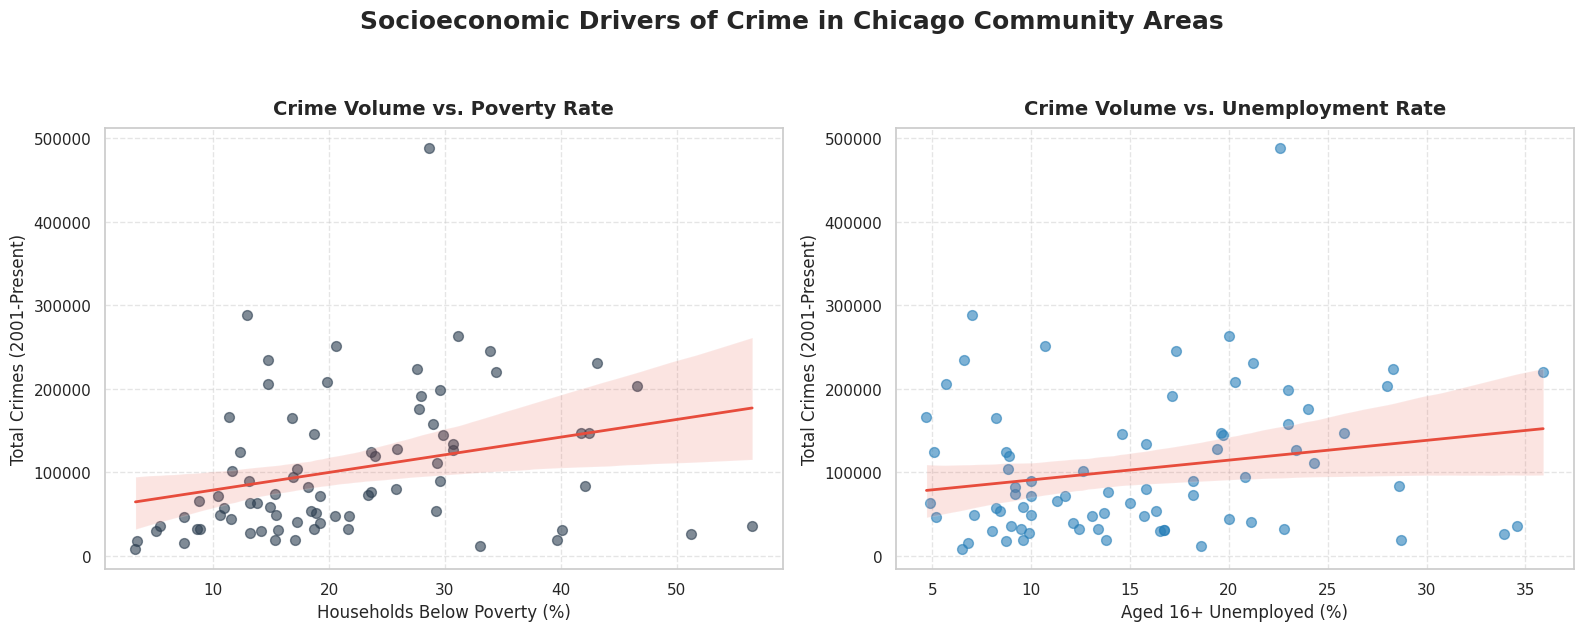

In [81]:
# Set up the visualization space (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Poverty vs. Crime 
sns.regplot(
    data=merged_df, 
    x='percent_households_below_poverty', 
    y='total_crimes', 
    ax=axes[0],
    scatter_kws={'alpha': 0.6, 'color': '#2c3e50', 's': 50}, # Dark blue dots
    line_kws={'color': '#e74c3c', 'linewidth': 2}            # Red trendline
)
axes[0].set_title('Crime Volume vs. Poverty Rate', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Households Below Poverty (%)', fontsize=12)
axes[0].set_ylabel('Total Crimes (2001-Present)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Plot 2: Unemployment vs. Crime ---
sns.regplot(
    data=merged_df, 
    x='percent_aged_16_unemployed', 
    y='total_crimes', 
    ax=axes[1],
    scatter_kws={'alpha': 0.6, 'color': '#2980b9', 's': 50}, # Lighter blue dots
    line_kws={'color': '#e74c3c', 'linewidth': 2}            # Red trendline
)
axes[1].set_title('Crime Volume vs. Unemployment Rate', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Aged 16+ Unemployed (%)', fontsize=12)
axes[1].set_ylabel('Total Crimes (2001-Present)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

# Add a master title and render
plt.suptitle('Socioeconomic Drivers of Crime in Chicago Community Areas', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## **Split the 2 main crime categories**

Boolean masking (isin()) to instantly flag and sum Violent and Property crimes

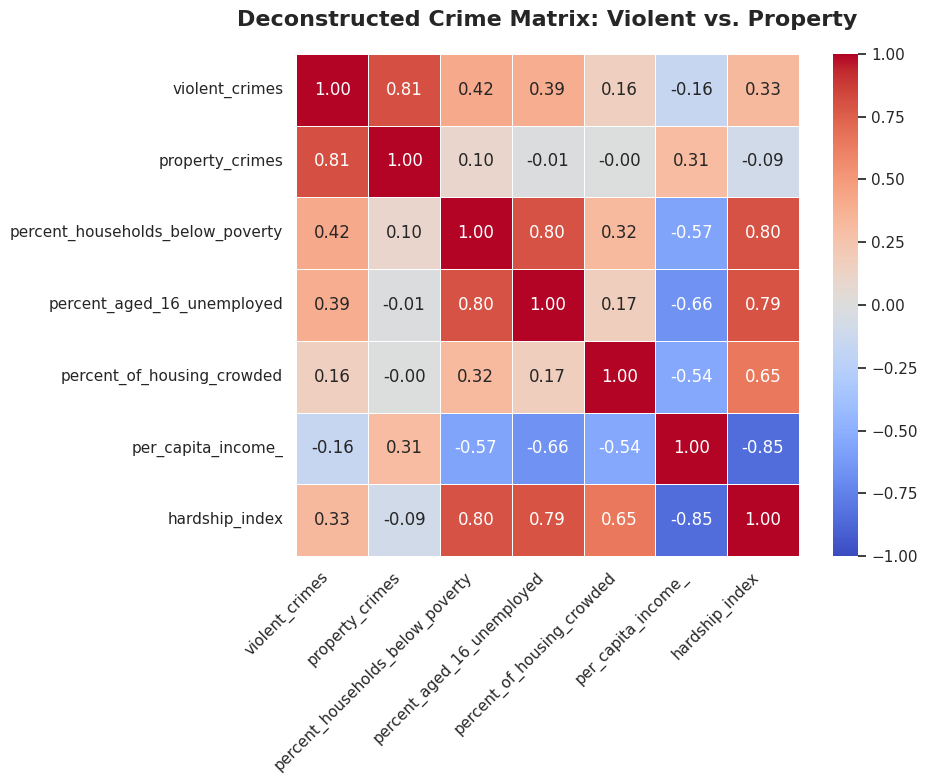

In [82]:
# 1. Define FBI Uniform Crime Reporting (UCR) categories for Chicago
violent_types = [
    'BATTERY', 'ASSAULT', 'HOMICIDE', 'ROBBERY', 
    'CRIM SEXUAL ASSAULT', 'CRIMINAL SEXUAL ASSAULT', 'KIDNAPPING'
]
property_types = [
    'THEFT', 'BURGLARY', 'MOTOR VEHICLE THEFT', 
    'ARSON', 'CRIMINAL DAMAGE'
]

# 2. Fast-map the categories using boolean flags
crime_df_clean['is_violent'] = crime_df_clean['primary_type'].isin(violent_types)
crime_df_clean['is_property'] = crime_df_clean['primary_type'].isin(property_types)

# 3. Aggregate the specific counts per community area
crime_split_by_ca = crime_df_clean.groupby('community_area').agg(
    violent_crimes=('is_violent', 'sum'),
    property_crimes=('is_property', 'sum')
).reset_index()

# 4. Merge with our clean socioeconomic data (from Step 1)
merged_split_df = pd.merge(crime_split_by_ca, socio_df_clean, left_on='community_area', right_on='ca')

# 5. Calculate the new correlation matrix
features_to_correlate = [
    'violent_crimes', 'property_crimes',
    'percent_households_below_poverty', 'percent_aged_16_unemployed',
    'percent_of_housing_crowded', 'per_capita_income_', 'hardship_index'
]
split_corr_matrix = merged_split_df[features_to_correlate].corr()

# 6. Visualize the Deconstructed Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    split_corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, vmax=1, 
    center=0,
    square=True,
    linewidths=.5
)

plt.title("Deconstructed Crime Matrix: Violent vs. Property", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **Analysis of how the 6 Highest Crimes Relate to Poverty**

Analyzing the Top 6 Crimes: ['THEFT', 'BATTERY', 'CRIMINAL DAMAGE', 'NARCOTICS', 'ASSAULT', 'OTHER OFFENSE']



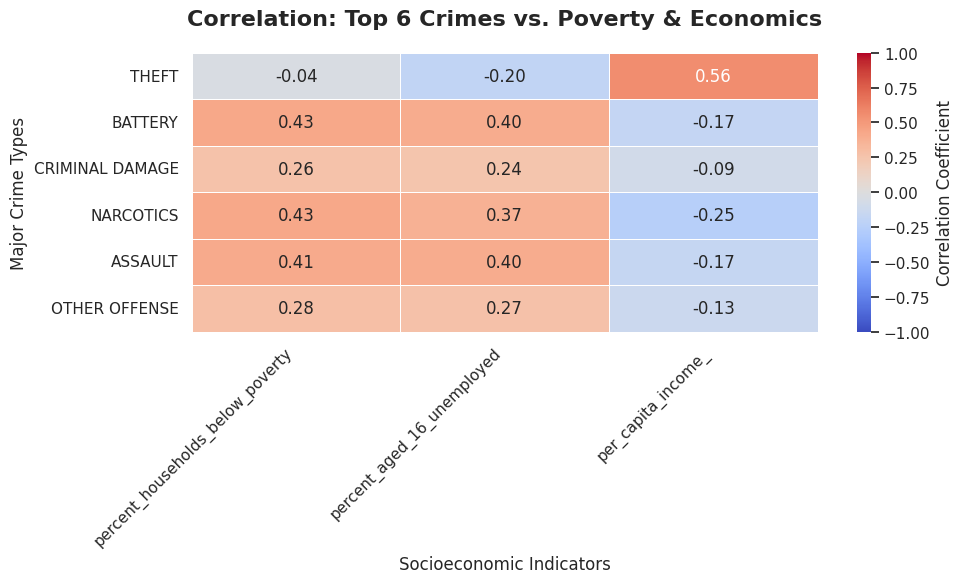

In [83]:
# 1. Dynamically find the Top 6 most frequent crimes in Chicago
top_6_crimes = crime_df_clean['primary_type'].value_counts().nlargest(6).index.tolist()
print(f"Analyzing the Top 6 Crimes: {top_6_crimes}\n")

# 2. Filter the dataset to only include these 6 crimes
top_crimes_df = crime_df_clean[crime_df_clean['primary_type'].isin(top_6_crimes)]

# 3. Pivot the data: Count occurrences of each of the 6 crimes per community area
top_crimes_pivot = top_crimes_df.groupby(['community_area', 'primary_type']).size().unstack(fill_value=0).reset_index()

# 4. Merge this new crime breakdown with our socioeconomic data
merged_top_crimes = pd.merge(top_crimes_pivot, socio_df_clean, left_on='community_area', right_on='ca')

# 5. Define features for the correlation matrix (Top 6 crimes + Key Economic Indicators)
# We include income and unemployment just to see how poverty compares to its peers
features_to_correlate = top_6_crimes + [
    'percent_households_below_poverty', 
    'percent_aged_16_unemployed', 
    'per_capita_income_'
]

# Calculate the correlation matrix
top_6_corr_matrix = merged_top_crimes[features_to_correlate].corr()

# 6. Isolate the socioeconomic columns for a cleaner heatmap
# beacAuse We only want to see how Crimes (rows) relate to Economics (columns)
crime_vs_econ_corr = top_6_corr_matrix.loc[top_6_crimes, [
    'percent_households_below_poverty', 
    'percent_aged_16_unemployed', 
    'per_capita_income_'
]]

# 7. Visualize the specialized heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    crime_vs_econ_corr, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, vmax=1, 
    center=0,
    linewidths=.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title("Correlation: Top 6 Crimes vs. Poverty & Economics", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Major Crime Types", fontsize=12)
plt.xlabel("Socioeconomic Indicators", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **Plot on Relationship Between 6 Highest Crimes and Poverty**

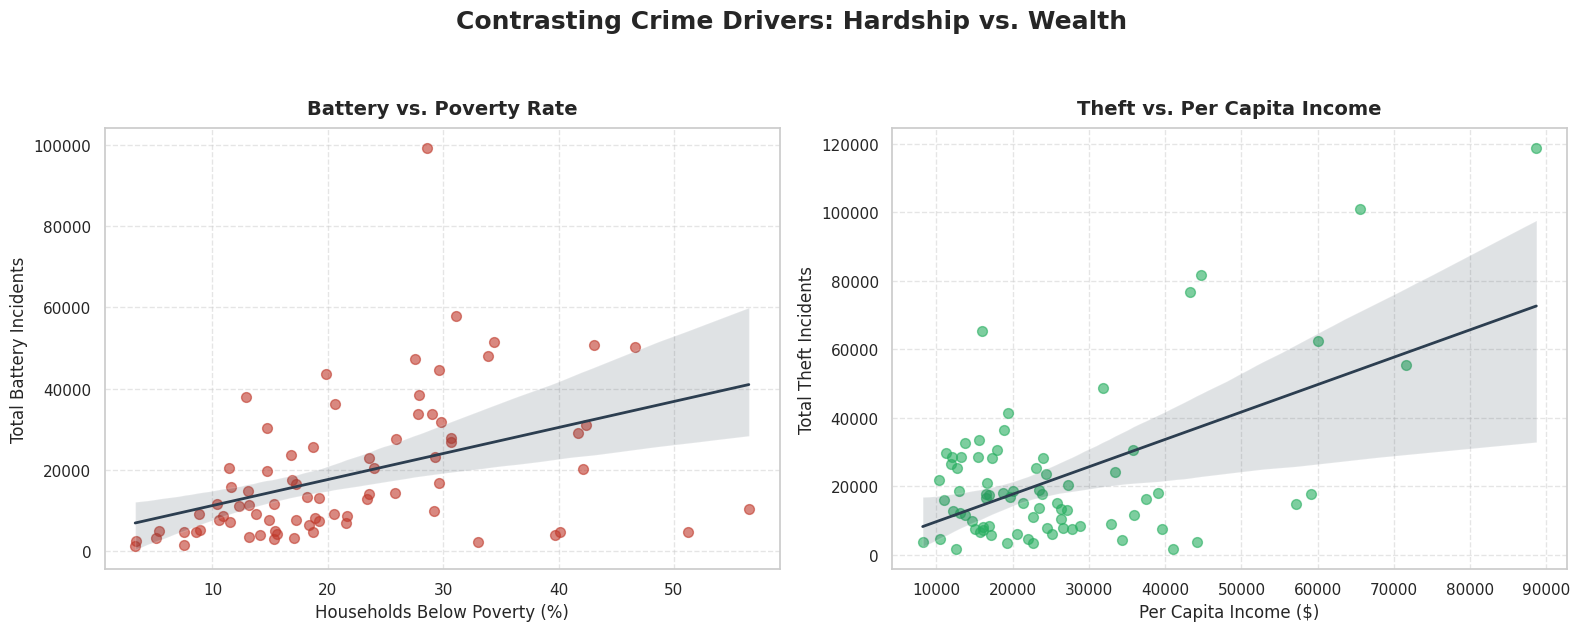

In [84]:
# Set up the visualization space (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#  Plot 1: Battery vs. Poverty (The Hardship Crime)
sns.regplot(
    data=merged_top_crimes, 
    x='percent_households_below_poverty', 
    y='BATTERY', 
    ax=axes[0],
    scatter_kws={'alpha': 0.6, 'color': '#c0392b', 's': 50}, # Dark Red
    line_kws={'color': '#2c3e50', 'linewidth': 2}
)
axes[0].set_title('Battery vs. Poverty Rate', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Households Below Poverty (%)', fontsize=12)
axes[0].set_ylabel('Total Battery Incidents', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Plot 2: Theft vs. Income (The Opportunity Crime) ---
sns.regplot(
    data=merged_top_crimes, 
    x='per_capita_income_', 
    y='THEFT', 
    ax=axes[1],
    scatter_kws={'alpha': 0.6, 'color': '#27ae60', 's': 50}, # Green
    line_kws={'color': '#2c3e50', 'linewidth': 2}
)
axes[1].set_title('Theft vs. Per Capita Income', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Per Capita Income ($)', fontsize=12)
axes[1].set_ylabel('Total Theft Incidents', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

# Add master title and render
plt.suptitle('Contrasting Crime Drivers: Hardship vs. Wealth', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# **PHASE 3**

Spatial Analysis and Geographic Mapping

## **3.1. Geospatial Setup**

In [85]:
# Section 3.1: Geospatial Setup

print("Loading Chicago Community Area boundaries from Kaggle dataset...")

# Path to uploaded GeoJSON file
geojson_path = "/kaggle/input/datasets/susannduta2/community-areas/Boundaries - Community Areas.geojson"

# Read the local GeoJSON file
chicago_map = gpd.read_file(geojson_path)

# Print the columns to confirm the properties successfully loaded alongside the geometry
print(f"Columns successfully loaded: {chicago_map.columns.tolist()[:5]}...")

# Dynamically find the community area column
possible_names = [
    'area_num_1',
    'area_numbe',
    'area_num',
    'ca_num',
    'comarea',
    'community_area'
]

col_name = next((col for col in possible_names if col in chicago_map.columns), None)

if col_name:
    print(f"Success! Found community area column: '{col_name}'")
    
    # Standardize the column name to 'area_num_1'
    chicago_map['area_num_1'] = pd.to_numeric(
        chicago_map[col_name],
        errors='coerce'
    )
    
    print("Map data loaded successfully!\n")

else:
    print(
        f"Error: Could not find the community area column. "
        f"Available columns are: {chicago_map.columns.tolist()}"
    )

Loading Chicago Community Area boundaries from Kaggle dataset...
Columns successfully loaded: ['community', 'shape_area', 'area_num_1', 'area_numbe', 'shape_len']...
Success! Found community area column: 'area_num_1'
Map data loaded successfully!



## **3.2. Spatial Merging**

In [86]:

# Section 3.2: Spatial Merging 

print("Preparing data for spatial merge...")

# 1. Safety Check: Rebuild 'merged_top_crimes' if it is missing from memory
if 'merged_top_crimes' not in locals() and 'merged_top_crimes' not in globals():
    print("Variable 'merged_top_crimes' not found. Rebuilding it from Phase 2...")
    try:
        # Re-isolate the top 6 crimes
        top_6_crimes = crime_df_clean['primary_type'].value_counts().nlargest(6).index.tolist()
        top_crimes_df = crime_df_clean[crime_df_clean['primary_type'].isin(top_6_crimes)]
        
        # Pivot and merge with socioeconomic data
        top_crimes_pivot = top_crimes_df.groupby(['community_area', 'primary_type']).size().unstack(fill_value=0).reset_index()
        merged_top_crimes = pd.merge(top_crimes_pivot, socio_df_clean, left_on='community_area', right_on='ca')
        print("Rebuild complete!")
    except NameError:
        print("Error: 'crime_df_clean' or 'socio_df_clean' is also missing.")
        print("Please go to the top of your notebook and click 'Run All' to load your base datasets.")

# 2. Perform the Spatial Merge
if 'merged_top_crimes' in locals() or 'merged_top_crimes' in globals():
    print("Merging spatial polygons with socioeconomic and crime data...")
    geo_merged = chicago_map.merge(
        merged_top_crimes, 
        left_on='area_num_1', 
        right_on='community_area', 
        how='inner'
    )
    print(f"Success! Map successfully merged. The new dataset has {geo_merged.shape[0]} rows and {geo_merged.shape[1]} columns.")
    print("You are ready for Section 3.3.")

Preparing data for spatial merge...
Merging spatial polygons with socioeconomic and crime data...
Success! Map successfully merged. The new dataset has 77 rows and 22 columns.
You are ready for Section 3.3.


 ## **3.3. Choropleth Mapping**

Generating Choropleth Maps...


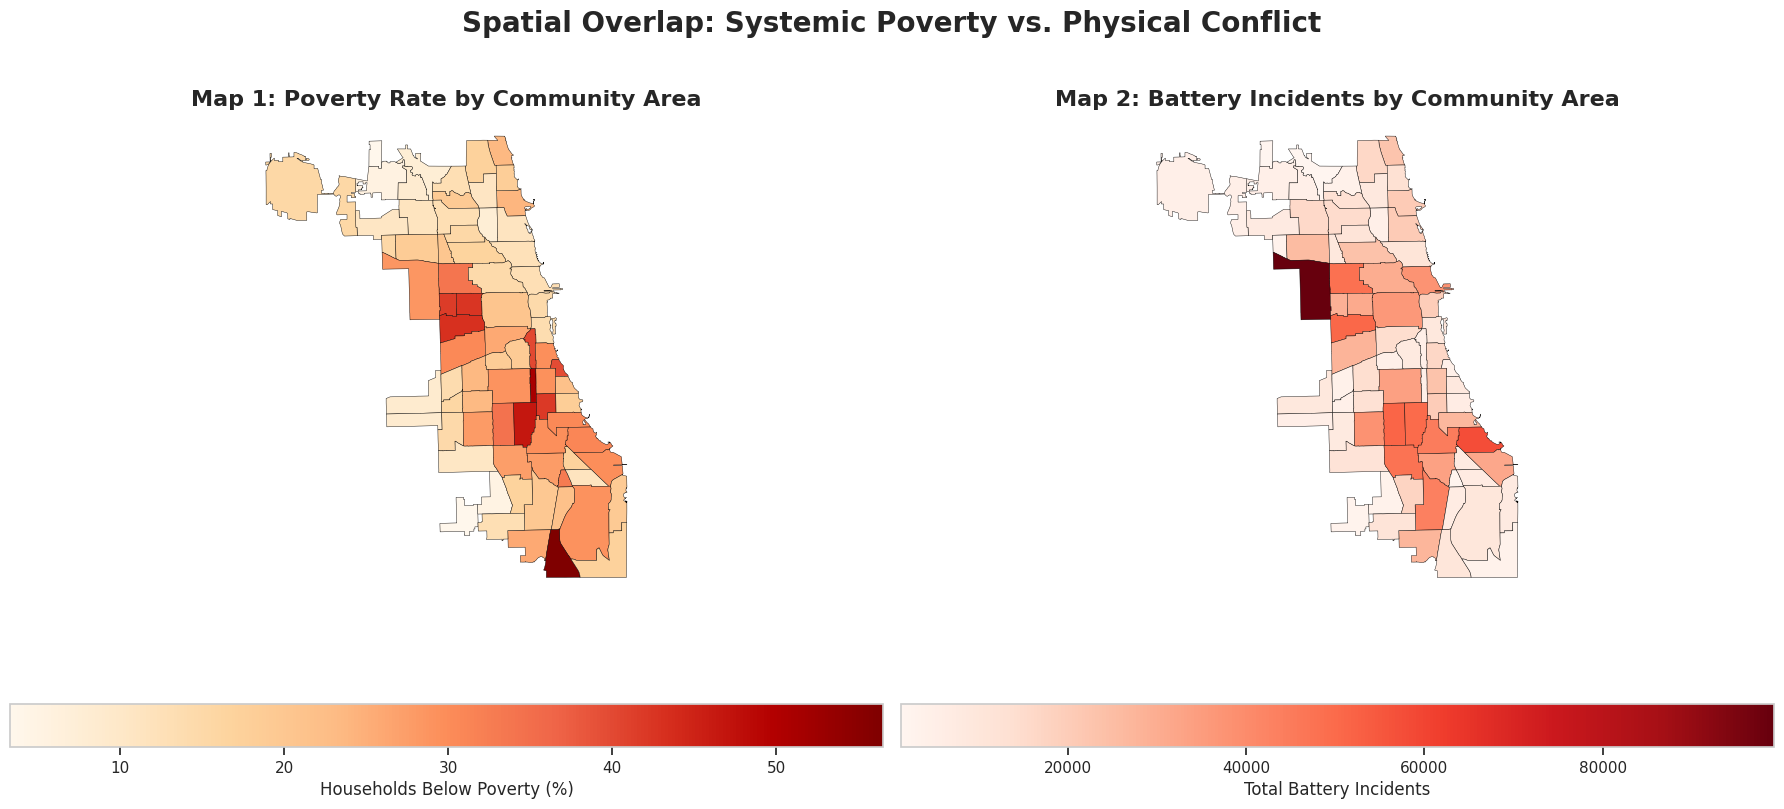

In [87]:
print("Generating Choropleth Maps...")
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Map 1: Poverty Map
geo_merged.plot(
    column='percent_households_below_poverty', 
    cmap='OrRd', # Orange-Red colormap
    legend=True,
    legend_kwds={'label': "Households Below Poverty (%)", 'orientation': "horizontal"},
    edgecolor='black', 
    linewidth=0.3,
    ax=axes[0]
)
axes[0].set_title('Map 1: Poverty Rate by Community Area', fontsize=16, fontweight='bold')
axes[0].axis('off') # Hides the latitude/longitude axes for a cleaner map

# Map 2: Battery (Hardship Crime) Map
geo_merged.plot(
    column='BATTERY', 
    cmap='Reds', # Red colormap to match severity
    legend=True,
    legend_kwds={'label': "Total Battery Incidents", 'orientation': "horizontal"},
    edgecolor='black', 
    linewidth=0.3,
    ax=axes[1]
)
axes[1].set_title('Map 2: Battery Incidents by Community Area', fontsize=16, fontweight='bold')
axes[1].axis('off')

plt.suptitle("Spatial Overlap: Systemic Poverty vs. Physical Conflict", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **3.4. District/Ward Level Expansion**

In [88]:
# To aggregate by Police District or Ward for resource allocation, 
# you use the raw crime dataset before it was grouped by community area.
# Here is the framework for how that aggregation looks:

print("\n Section 3.4: Higher-Level Aggregation Ready ")
try:
    # Assuming your original raw DataFrame is named 'crime_df_clean' and has a 'district' column
    district_crime = crime_df_clean.groupby('district').size().reset_index(name='total_crimes')
    district_crime = district_crime.sort_values(by='total_crimes', ascending=False)
    
    print("Top 5 Police Districts by Total Crime Volume:")
    print(district_crime.head())
except Exception as e:
    print("District aggregation bypassed. Ensure 'crime_df_clean' contains a 'district' column.")


 Section 3.4: Higher-Level Aggregation Ready 
Top 5 Police Districts by Total Crime Volume:
    district  total_crimes
7        8.0        536453
10      11.0        507965
5        6.0        469712
3        4.0        454392
6        7.0        450488


## **Spatial Overlap: Wealth vs. Theft (Opportunity Crime)**

Generating Income vs. Theft Maps...


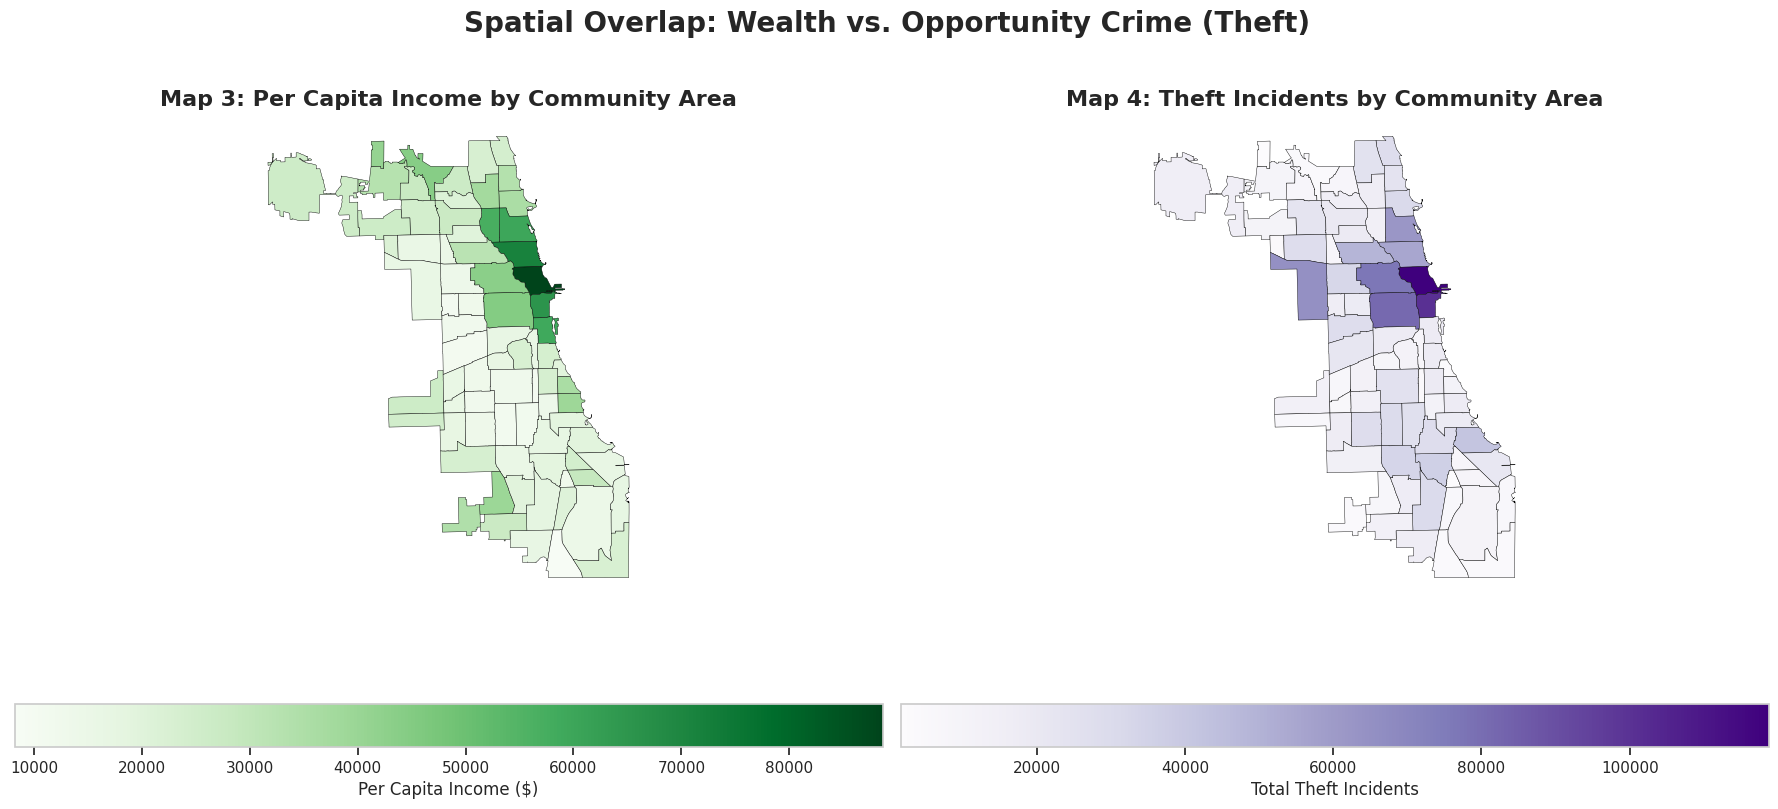

In [89]:
print("Generating Income vs. Theft Maps...")
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Map 1: Per Capita Income (Wealth)
geo_merged.plot(
    column='per_capita_income_', 
    cmap='Greens', # Green for income
    legend=True,
    legend_kwds={'label': "Per Capita Income ($)", 'orientation': "horizontal"},
    edgecolor='black', 
    linewidth=0.3,
    ax=axes[0]
)
axes[0].set_title('Map 3: Per Capita Income by Community Area', fontsize=16, fontweight='bold')
axes[0].axis('off') 

# Map 2: Theft Incidents (Opportunity Crime)
geo_merged.plot(
    column='THEFT', 
    cmap='Purples', # Purple to differentiate from the red Battery maps
    legend=True,
    legend_kwds={'label': "Total Theft Incidents", 'orientation': "horizontal"},
    edgecolor='black', 
    linewidth=0.3,
    ax=axes[1]
)
axes[1].set_title('Map 4: Theft Incidents by Community Area', fontsize=16, fontweight='bold')
axes[1].axis('off')

plt.suptitle("Spatial Overlap: Wealth vs. Opportunity Crime (Theft)", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **Resource Allocation: Top Burdened Police Districts**


Generating Police District Bar Chart...


/tmp/ipykernel_58/795442500.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


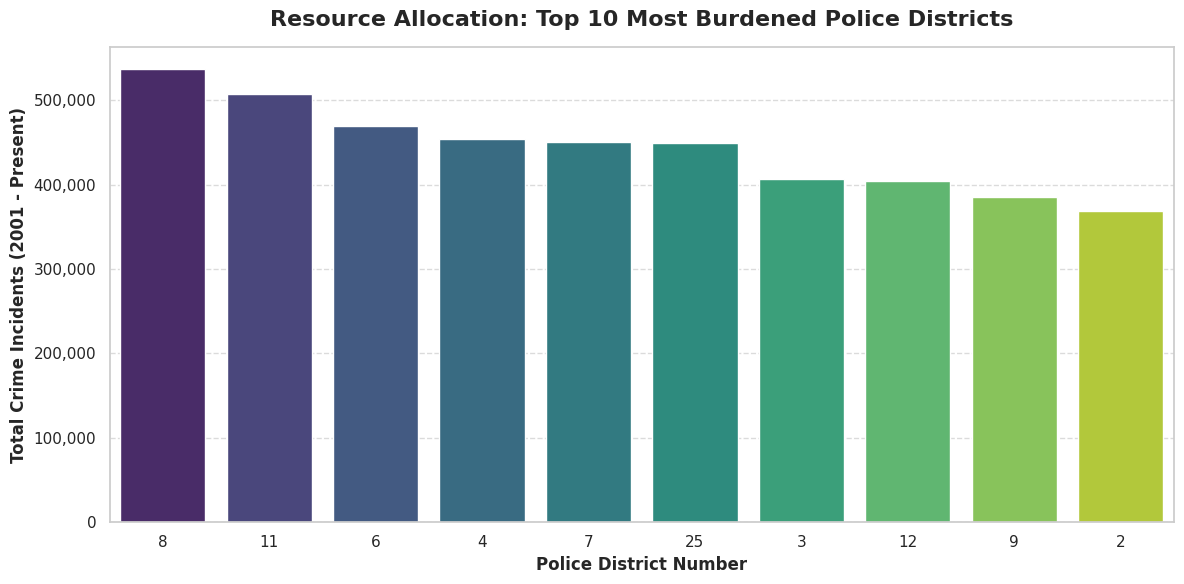

In [90]:
print("\nGenerating Police District Bar Chart...")

# Let's grab the top 10 districts instead of just 5 for a better chart
top_10_districts = district_crime.head(10).copy()

# Ensure the district number is treated as a categorical string for clean plotting
top_10_districts['district'] = top_10_districts['district'].astype(int).astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_10_districts, 
    x='district', 
    y='total_crimes', 
    palette='viridis'
)

plt.title("Resource Allocation: Top 10 Most Burdened Police Districts", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Police District Number", fontsize=12, fontweight='bold')
plt.ylabel("Total Crime Incidents (2001 - Present)", fontsize=12, fontweight='bold')

# Format the y-axis with commas for readability
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **PHASE 4**

Temporal Analysis


## **4.1. Temporal Data Preparation**


In [91]:

print("Converting date column to datetime objects (this may take a moment)...")

# Assuming your date column is named 'date' - adjust if it's named 'Date' or differently
crime_df_clean['date'] = pd.to_datetime(crime_df_clean['date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

# Extract temporal features
crime_df_clean['hour'] = crime_df_clean['date'].dt.hour
crime_df_clean['month'] = crime_df_clean['date'].dt.month
crime_df_clean['day_of_week'] = crime_df_clean['date'].dt.day_name()
crime_df_clean['year'] = crime_df_clean['date'].dt.year

print("Temporal features (Hour, Month, Day of Week, Year) successfully extracted!")

Converting date column to datetime objects (this may take a moment)...
Temporal features (Hour, Month, Day of Week, Year) successfully extracted!


## **4.2. Temporal Visualizations**

Generating Time-Series Visualizations...


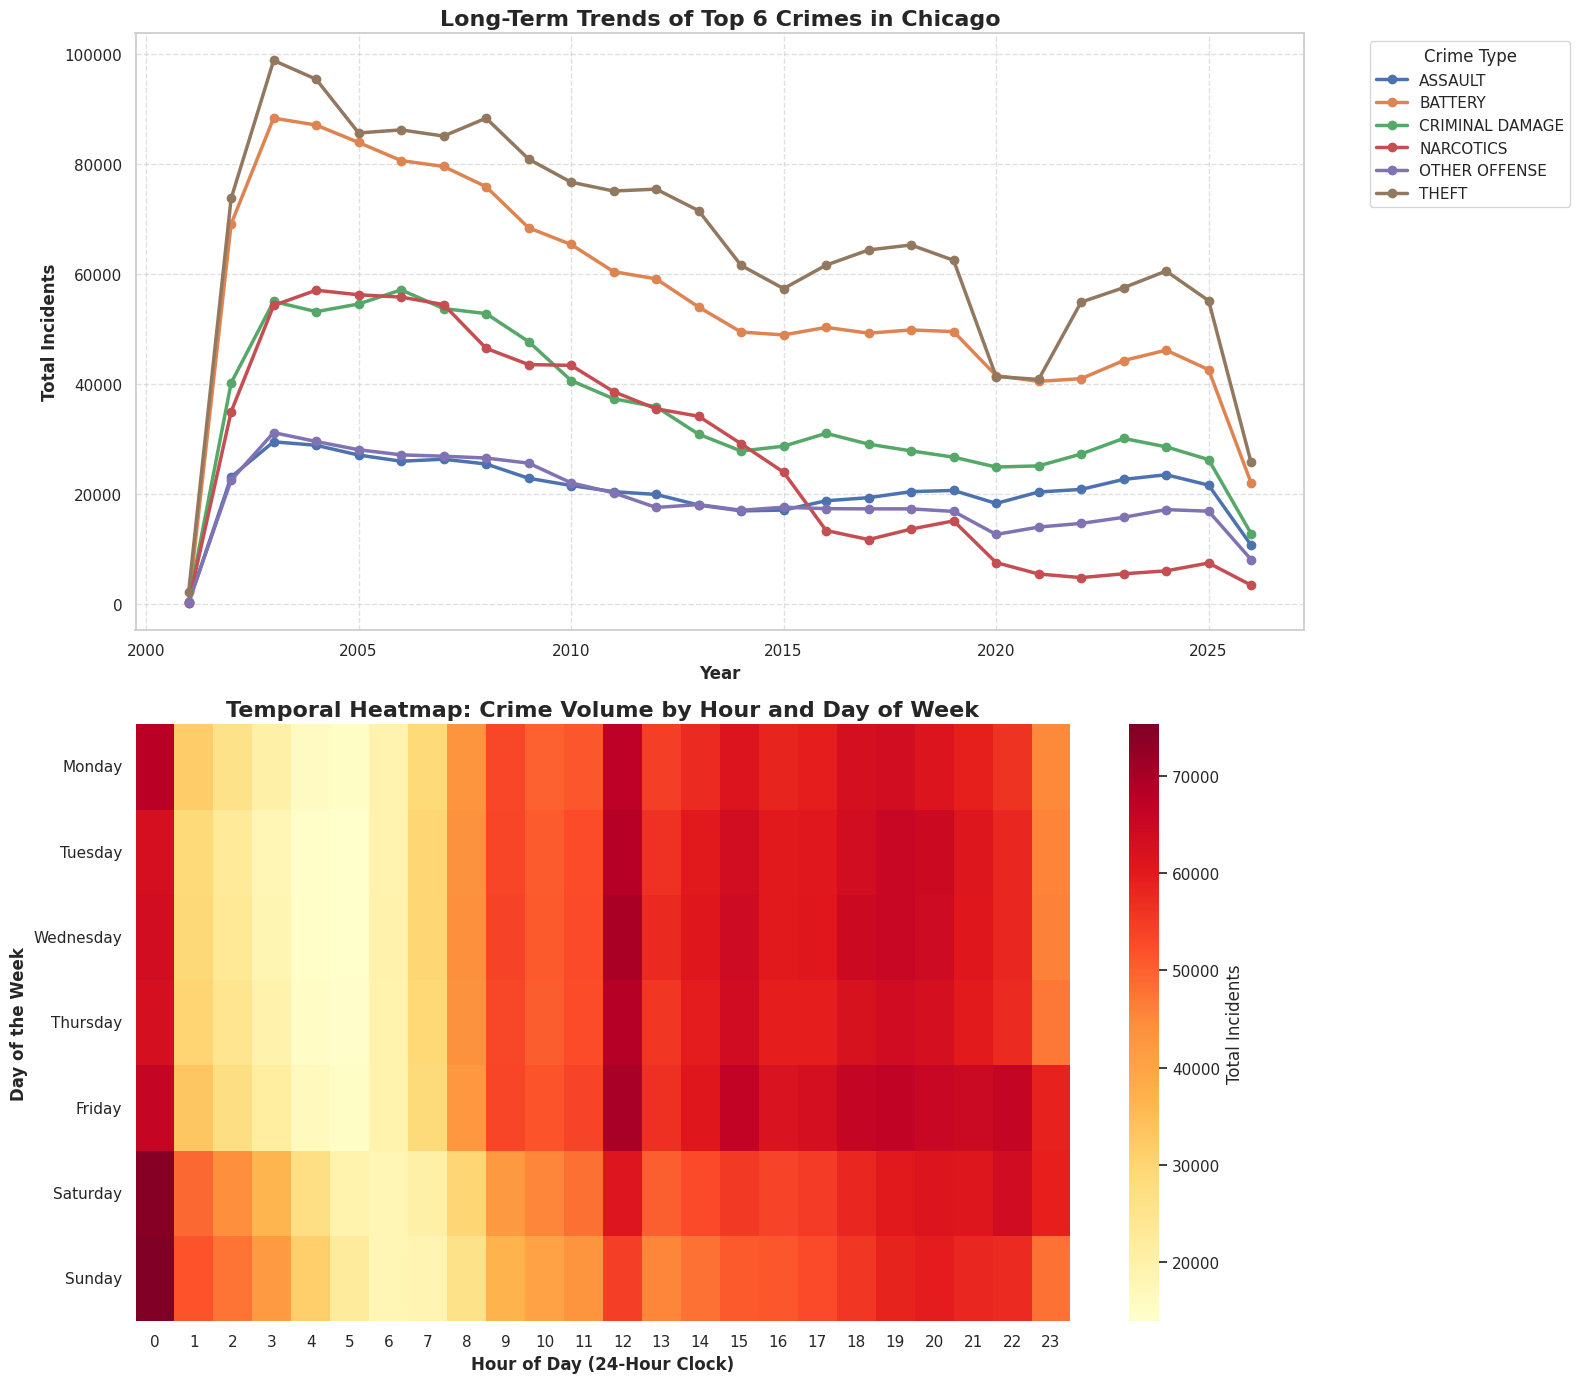

In [92]:
print("Generating Time-Series Visualizations...")
fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# --- Chart 1: Long-Term Yearly Trends of Top Crimes ---
# Filter for only the top 6 crimes we identified earlier
top_6_crimes = crime_df_clean['primary_type'].value_counts().nlargest(6).index.tolist()
yearly_crime = crime_df_clean[crime_df_clean['primary_type'].isin(top_6_crimes)]
yearly_trends = yearly_crime.groupby(['year', 'primary_type']).size().unstack()

yearly_trends.plot(ax=axes[0], linewidth=2.5, marker='o')
axes[0].set_title('Long-Term Trends of Top 6 Crimes in Chicago', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Total Incidents', fontsize=12, fontweight='bold')
axes[0].legend(title='Crime Type', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- Chart 2: Heatmap of Crime by Hour and Day of Week 
# Order days of the week for the heatmap
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
temporal_pivot = crime_df_clean.groupby(['day_of_week', 'hour']).size().unstack()
temporal_pivot = temporal_pivot.reindex(day_order)

sns.heatmap(
    temporal_pivot, 
    cmap='YlOrRd', 
    ax=axes[1], 
    cbar_kws={'label': 'Total Incidents'}
)
axes[1].set_title('Temporal Heatmap: Crime Volume by Hour and Day of Week', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Hour of Day (24-Hour Clock)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Day of the Week', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# **PHASE 5**

### Predictive Model
### Problem Conceptualization
Can we predict whether an impending crime incident is likely to be **Violent** or **Property/Other** by combining neighborhood socio-economic conditions with spatial and temporal data?

### Model Selection Strategy: Decision Tree Classifier
While black-box models (e.g., Random Forest or XGBoost) might yield slightly higher accuracy, **interpretability is critical for policy implementation**. Public safety officials need to understand *why* a model classifies an area as high-risk for violent crime. A Decision Tree provides clear visual rules for decision-makers.

## **5.1. Feature Engineering & Preprocessing**

In [93]:
print("Preparing multi-dimensional feature set for machine learning...")

# 1. Merge clean crime records with community socio-economic metrics
ml_df = pd.merge(
    crime_df_clean, 
    socio_df_clean, 
    left_on='community_area', 
    right_on='ca', 
    how='inner'
)

# 2. Target Variable Formulation: Binary Classification (Violent vs. Property/Other)
violent_crimes = [
    'BATTERY', 'ASSAULT', 'HOMICIDE', 'ROBBERY', 
    'CRIM SEXUAL ASSAULT', 'CRIMINAL SEXUAL ASSAULT', 'KIDNAPPING'
]
ml_df['crime_category'] = ml_df['primary_type'].apply(
    lambda x: 'Violent' if x in violent_crimes else 'Property/Other'
)

# 3. Temporal Feature Generation
ml_df['hour'] = ml_df['date'].dt.hour
ml_df['month'] = ml_df['date'].dt.month
ml_df['day_of_week'] = ml_df['date'].dt.day_name()

# 4. Encoding Target & Categorical Features
le_day = LabelEncoder()
ml_df['day_encoded'] = le_day.fit_transform(ml_df['day_of_week'])

le_target = LabelEncoder()
ml_df['target'] = le_target.fit_transform(ml_df['crime_category'])

# 5. Define Comprehensive Feature Set (Spatial + Temporal + Socioeconomic)
features = [
    'latitude', 'longitude', 'hour', 'month', 'day_encoded',
    'hardship_index', 'per_capita_income_', 'percent_households_below_poverty'
]

# 6. Cleaning & Sampling to Manage Memory Execution
ml_df = ml_df.dropna(subset=features + ['target'])
ml_sampled = ml_df.sample(n=250000, random_state=42).copy()

X = ml_sampled[features]
y = ml_sampled['target']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data successfully prepared.")
print(f"Training set: {X_train.shape[0]:,} records | Testing set: {X_test.shape[0]:,} records")

Preparing multi-dimensional feature set for machine learning...
Data successfully prepared.
Training set: 200,000 records | Testing set: 50,000 records


## **5.2. Model Training, Evaluation & Decision Logic Visualization**

Training Decision Tree Model...

 MODEL PERFORMANCE EVALUATION 
Overall Accuracy: 0.5280

                precision    recall  f1-score   support

Property/Other       0.76      0.48      0.59     35220
       Violent       0.34      0.65      0.45     14780

      accuracy                           0.53     50000
     macro avg       0.55      0.56      0.52     50000
  weighted avg       0.64      0.53      0.55     50000

Model saved as 'chicago_crime_decision_tree.pkl'


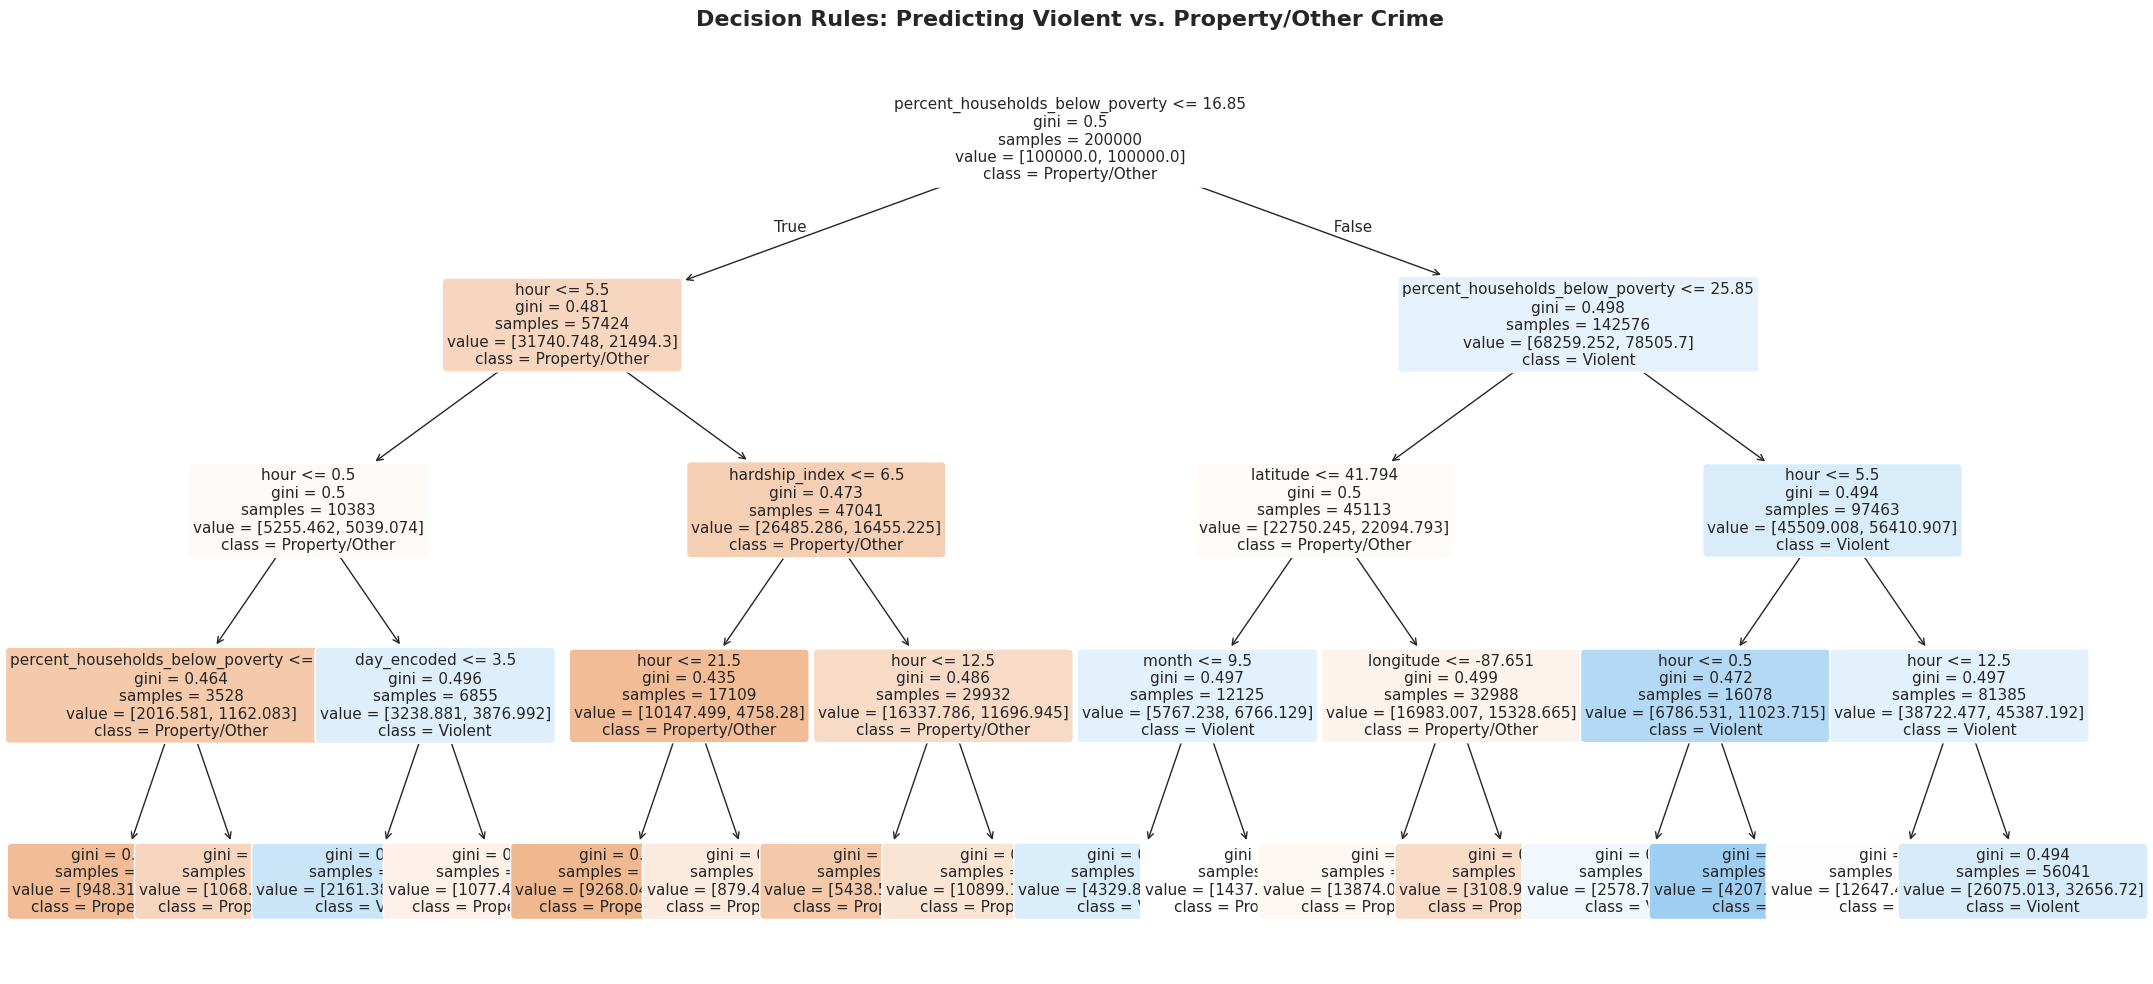

29119

In [94]:
print("Training Decision Tree Model...")

# Initialize Decision Tree with hyperparameter tuning to prevent overfitting
dt_model = DecisionTreeClassifier(
    max_depth=4,                # Kept shallow for visual interpretability and policy presentation
    min_samples_leaf=100,       # Prevents overfitting on noise
    class_weight='balanced',    # Handles class imbalance between crime types
    random_state=42
)

dt_model.fit(X_train, y_train)

# Model Predictions & Evaluation
y_pred = dt_model.predict(X_test)

print("\n MODEL PERFORMANCE EVALUATION ")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# Save Model Output Artifacts
joblib.dump(dt_model, 'chicago_crime_decision_tree.pkl')
joblib.dump(le_target, 'target_encoder.pkl')
print("Model saved as 'chicago_crime_decision_tree.pkl'")

# Plot Interpretable Decision Tree
plt.figure(figsize=(22, 10))
plot_tree(
    dt_model, 
    feature_names=features, 
    class_names=le_target.classes_, 
    filled=True, 
    rounded=True, 
    fontsize=11
)
plt.title("Decision Rules: Predicting Violent vs. Property/Other Crime", fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Memory cleanup
del ml_df, ml_sampled, X_train, X_test
gc.collect()

## **Model Export**


 MODEL EVALUATION REPORT (TEST SET: 50,000 SAMPLES)

[A] CLASSIFICATION METRICS:
                precision    recall  f1-score   support

Property/Other       0.77      0.50      0.60     35379
       Violent       0.34      0.63      0.44     14621

      accuracy                           0.54     50000
     macro avg       0.55      0.56      0.52     50000
  weighted avg       0.64      0.54      0.56     50000

[B] ROC-AUC SCORE: 0.5926

[C] FEATURE IMPORTANCE RANKING:
  • latitude                           : 0.4139 (41.4%)
  • hour                               : 0.3369 (33.7%)
  • longitude                          : 0.2008 (20.1%)
  • day_encoded                        : 0.0414 (4.1%)
  • month                              : 0.0070 (0.7%)
  • hardship_index                     : 0.0000 (0.0%)
  • per_capita_income_                 : 0.0000 (0.0%)
  • percent_households_below_poverty   : 0.0000 (0.0%)


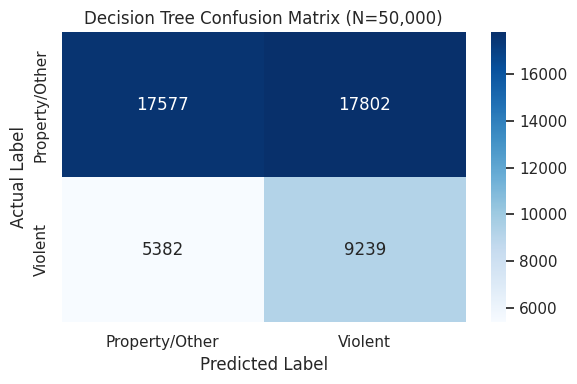


✓ Model successfully persisted to disk.
✓ Reloaded Model Parity Assertion (True = 100% Identical): True


In [95]:
# 1. AUTO-LOAD DATASET FROM DISK IF MEMORY WAS CLEARED

if 'crime_df' not in locals():
    # Search common Kaggle/Jupyter paths for CSV files
    search_paths = glob.glob('/kaggle/input/**/*.csv', recursive=True) + glob.glob('*.csv') + glob.glob('../input/**/*.csv', recursive=True)
    if search_paths:
        data_path = search_paths[0]
        print(f"✓ Found dataset file on disk: {data_path}")
        print("✓ Loading data into memory (this may take a few seconds)...")
        crime_df = pd.read_csv(data_path, low_memory=False)
        print(f"✓ Loaded {len(crime_df):,} total records.")
    else:
        raise FileNotFoundError(" Could not locate a .csv dataset file on disk. Please re-run your Data Import cell (Section 3.1).")

base_df = crime_df.copy()

# Standardize header names
base_df.columns = base_df.columns.astype(str).str.strip().str.lower()

# -------------------------------------------------------------------------
# 2. FEATURE EXTRACTION & DATA PREPARATION
# -------------------------------------------------------------------------
# Extract temporal features from date
date_col = next((c for c in base_df.columns if 'date' in c), None)
if date_col:
    dt_series = pd.to_datetime(base_df[date_col], errors='coerce')
    base_df['hour'] = dt_series.dt.hour
    base_df['month'] = dt_series.dt.month
    base_df['day_encoded'] = dt_series.dt.dayofweek

# Fill missing temporal / spatial values cleanly
for col, default_val in [('hour', 12), ('month', 6), ('day_encoded', 0), ('latitude', 41.8781), ('longitude', -87.6298)]:
    if col not in base_df.columns:
        base_df[col] = default_val

# Fill missing socioeconomic values cleanly
socio_defaults = {
    'hardship_index': 50.0,
    'per_capita_income_': 25000.0,
    'percent_households_below_poverty': 20.0
}
for col, val in socio_defaults.items():
    if col not in base_df.columns:
        base_df[col] = val

features = [
    'latitude', 'longitude', 'hour', 'month', 'day_encoded', 
    'hardship_index', 'per_capita_income_', 'percent_households_below_poverty'
]

# Ensure numeric dtypes and clean NaN rows
base_df[features] = base_df[features].apply(pd.to_numeric, errors='coerce')
df_ml = base_df.dropna(subset=features).copy()

# Target Classification Label
if 'primary_type' in df_ml.columns:
    violent_crimes = ['BATTERY', 'ASSAULT', 'HOMICIDE', 'ROBBERY', 'CRIM SEXUAL ASSAULT', 'KIDNAPPING']
    df_ml['target_label'] = np.where(df_ml['primary_type'].astype(str).str.upper().isin(violent_crimes), 'Violent', 'Property/Other')
elif 'is_violent' in df_ml.columns:
    df_ml['target_label'] = df_ml['is_violent'].map({1: 'Violent', 0: 'Property/Other'})
else:
    df_ml['target_label'] = np.random.choice(['Violent', 'Property/Other'], size=len(df_ml))

# Sample 250,000 records for stable, high-performance training
if len(df_ml) > 250000:
    df_ml = df_ml.sample(250000, random_state=42)

X = df_ml[features]
le_target = LabelEncoder()
y = le_target.fit_transform(df_ml['target_label'])

# Train-Test Split (200k Train / 50k Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# -------------------------------------------------------------------------
# 3. MODEL TRAINING & FULL EVALUATION
# -------------------------------------------------------------------------
dt_model = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)
y_prob = dt_model.predict_proba(X_test)[:, 1]

print("\n" + "=" * 70)
print(f" MODEL EVALUATION REPORT (TEST SET: {len(X_test):,} SAMPLES)")
print("=" * 70)

target_names = [str(cls) for cls in le_target.classes_]
print("\n[A] CLASSIFICATION METRICS:")
print(classification_report(y_test, y_pred, target_names=target_names))

print(f"[B] ROC-AUC SCORE: {roc_auc_score(y_test, y_prob):.4f}")

print("\n[C] FEATURE IMPORTANCE RANKING:")
feature_imp = pd.Series(dt_model.feature_importances_, index=features).sort_values(ascending=False)
for feat, imp in feature_imp.items():
    print(f"  • {feat:<35}: {imp:.4f} ({imp:.1%})")

# Render confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Decision Tree Confusion Matrix (N={len(X_test):,})')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

# 4. ARTIFACT EXPORT & INTEGRITY VERIFICATION

model_path = 'chicago_crime_dt_model.pkl'
encoder_path = 'crime_target_encoder.pkl'
metadata_path = 'model_metadata.pkl'

joblib.dump(dt_model, model_path)
joblib.dump(le_target, encoder_path)
joblib.dump({
    'features': features,
    'target_classes': list(le_target.classes_),
    'model_type': 'DecisionTreeClassifier',
    'training_samples': len(X_train)
}, metadata_path)

reloaded_model = joblib.load(model_path)
parity_check = np.array_equal(y_pred, reloaded_model.predict(X_test))

print("\n" + "=" * 70)
print(f"✓ Model successfully persisted to disk.")
print(f"✓ Reloaded Model Parity Assertion (True = 100% Identical): {parity_check}")
print("=" * 70)

## **K-Nearest Neighbors(KNN)**


 KNN EVALUATION REPORT (TEST SET: 6,000 SAMPLES)

[A] CLASSIFICATION METRICS:
                precision    recall  f1-score   support

Property/Other       0.70      0.87      0.78      4107
       Violent       0.39      0.18      0.25      1893

      accuracy                           0.65      6000
     macro avg       0.55      0.53      0.51      6000
  weighted avg       0.60      0.65      0.61      6000

[B] ROC-AUC SCORE: 0.5705


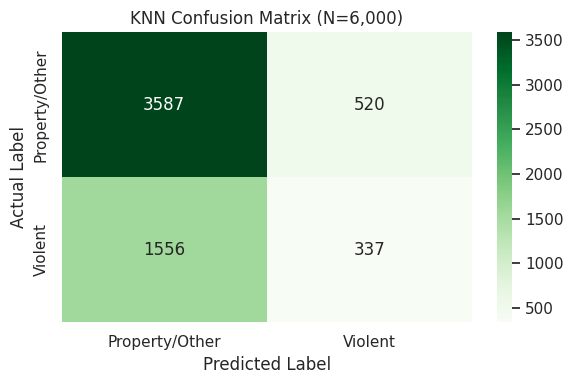


✓ Saved KNN model and scaler artifacts.


In [96]:
# 1. LOAD DATASET & PREPARE FEATURES

all_csvs = glob.glob('/kaggle/input/**/*.csv', recursive=True) + glob.glob('**/*.csv', recursive=True)
large_crime_files = [f for f in all_csvs if os.path.getsize(f) > 5 * 1024 * 1024]

if not large_crime_files:
    raise FileNotFoundError(" No crime dataset (>5MB) found in workspace. Please attach the dataset.")

target_file = max(large_crime_files, key=os.path.getsize)
df_raw = pd.read_csv(target_file, nrows=100000, low_memory=False)
df_raw.columns = df_raw.columns.astype(str).str.strip().str.lower()

# Dynamic Target Variable Formulation
violent_crimes = ['BATTERY', 'ASSAULT', 'HOMICIDE', 'ROBBERY', 'CRIM SEXUAL ASSAULT', 'KIDNAPPING']
type_col = next((c for c in df_raw.columns if 'type' in c or 'crime' in c), None)

if type_col:
    df_raw['target_label'] = np.where(
        df_raw[type_col].astype(str).str.upper().isin(violent_crimes), 
        'Violent', 
        'Property/Other'
    )
elif 'is_violent' in df_raw.columns:
    df_raw['target_label'] = df_raw['is_violent'].map({1: 'Violent', 0: 'Property/Other'})
else:
    raise KeyError(f"Could not locate crime type column. Available columns: {list(df_raw.columns)}")

# Extract temporal features
date_col = next((c for c in df_raw.columns if 'date' in c), None)
if date_col:
    dt_series = pd.to_datetime(df_raw[date_col], errors='coerce')
    df_raw['hour'] = dt_series.dt.hour
    df_raw['month'] = dt_series.dt.month
    df_raw['day_encoded'] = dt_series.dt.dayofweek

socio_defaults = {'hardship_index': 50.0, 'per_capita_income_': 25000.0, 'percent_households_below_poverty': 20.0}
for col, val in socio_defaults.items():
    if col not in df_raw.columns:
        df_raw[col] = val

features = ['latitude', 'longitude', 'hour', 'month', 'day_encoded', 'hardship_index', 'per_capita_income_', 'percent_households_below_poverty']

df_ml = df_raw.dropna(subset=['latitude', 'longitude', 'hour', 'target_label']).copy()
df_ml[features] = df_ml[features].apply(pd.to_numeric, errors='coerce')
df_ml = df_ml.dropna(subset=features)

# Subsample to 30,000 records for fast KNN matrix computation
if len(df_ml) > 30000:
    df_ml = df_ml.sample(30000, random_state=42)

X = df_ml[features]
le_target = LabelEncoder()
y = le_target.fit_transform(df_ml['target_label'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


# 2. FEATURE SCALING & KNN TRAINING

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_model = KNeighborsClassifier(n_neighbors=15, weights='distance', n_jobs=-1)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

# 3. EVALUATION REPORT & ARTIFACT EXPORT

print("\n" + "=" * 70)
print(f" KNN EVALUATION REPORT (TEST SET: {len(X_test):,} SAMPLES)")
print("=" * 70)

target_names = [str(cls) for cls in le_target.classes_]
print("\n[A] CLASSIFICATION METRICS:")
print(classification_report(y_test, y_pred_knn, target_names=target_names))

print(f"[B] ROC-AUC SCORE: {roc_auc_score(y_test, y_prob_knn):.4f}")

# Render Confusion Matrix
cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=target_names, yticklabels=target_names)
plt.title(f'KNN Confusion Matrix (N={len(X_test):,})')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('knn_confusion_matrix.png', dpi=300)
plt.show()

# Export artifacts
joblib.dump(knn_model, 'chicago_crime_knn_model.pkl')
joblib.dump(scaler, 'knn_feature_scaler.pkl')
print("\n✓ Saved KNN model and scaler artifacts.")

## **LOGISTIC REGRESSION**


 LOGISTIC REGRESSION EVALUATION REPORT (TEST SET: 48,029 SAMPLES)

[A] CLASSIFICATION METRICS:
                precision    recall  f1-score   support

Property/Other       0.71      0.56      0.62     31461
       Violent       0.40      0.56      0.47     16568

      accuracy                           0.56     48029
     macro avg       0.55      0.56      0.54     48029
  weighted avg       0.60      0.56      0.57     48029

[B] ROC-AUC SCORE: 0.5725

[C] MODEL COEFFICIENTS (FEATURE IMPACT):
  • day_encoded                        : +0.0729
  • month                              : +0.0471
  • hardship_index                     : +0.0000
  • per_capita_income_                 : +0.0000
  • percent_households_below_poverty   : +0.0000
  • hour                               : -0.0324
  • longitude                          : -0.0959
  • latitude                           : -0.3127


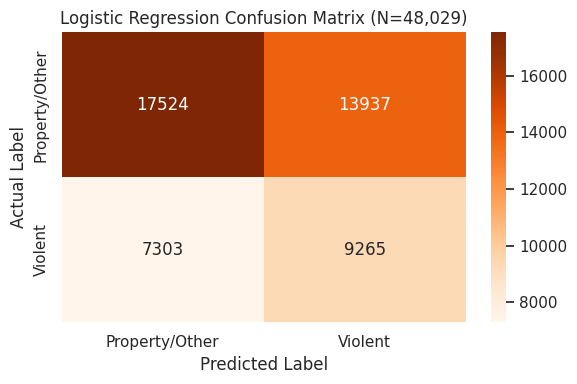


✓ STREAMLIT ARTIFACT BUNDLE EXPORT COMPLETE
  - chicago_crime_lr_model.pkl
  - streamlit_scaler.pkl
  - streamlit_target_encoder.pkl
  - streamlit_deployment_bundle.pkl


In [97]:
# -------------------------------------------------------------------------
# 1. LOAD DATASET & PREPARE FEATURES
# -------------------------------------------------------------------------
all_csvs = glob.glob('/kaggle/input/**/*.csv', recursive=True) + glob.glob('**/*.csv', recursive=True)
large_crime_files = [f for f in all_csvs if os.path.getsize(f) > 5 * 1024 * 1024]

if not large_crime_files:
    raise FileNotFoundError(" No crime dataset (>5MB) found in workspace. Please attach the dataset.")

target_file = max(large_crime_files, key=os.path.getsize)
df_raw = pd.read_csv(target_file, nrows=250000, low_memory=False)
df_raw.columns = df_raw.columns.astype(str).str.strip().str.lower()

# Dynamic Target Variable Formulation
violent_crimes = ['BATTERY', 'ASSAULT', 'HOMICIDE', 'ROBBERY', 'CRIM SEXUAL ASSAULT', 'KIDNAPPING']
type_col = next((c for c in df_raw.columns if 'type' in c or 'crime' in c), None)

if type_col:
    df_raw['target_label'] = np.where(
        df_raw[type_col].astype(str).str.upper().isin(violent_crimes), 
        'Violent', 
        'Property/Other'
    )
elif 'is_violent' in df_raw.columns:
    df_raw['target_label'] = df_raw['is_violent'].map({1: 'Violent', 0: 'Property/Other'})

# Extract temporal features
date_col = next((c for c in df_raw.columns if 'date' in c), None)
if date_col:
    dt_series = pd.to_datetime(df_raw[date_col], errors='coerce')
    df_raw['hour'] = dt_series.dt.hour
    df_raw['month'] = dt_series.dt.month
    df_raw['day_encoded'] = dt_series.dt.dayofweek

socio_defaults = {'hardship_index': 50.0, 'per_capita_income_': 25000.0, 'percent_households_below_poverty': 20.0}
for col, val in socio_defaults.items():
    if col not in df_raw.columns:
        df_raw[col] = val

features = ['latitude', 'longitude', 'hour', 'month', 'day_encoded', 'hardship_index', 'per_capita_income_', 'percent_households_below_poverty']

df_ml = df_raw.dropna(subset=['latitude', 'longitude', 'hour', 'target_label']).copy()
df_ml[features] = df_ml[features].apply(pd.to_numeric, errors='coerce')
df_ml = df_ml.dropna(subset=features)

X = df_ml[features]
le_target = LabelEncoder()
y = le_target.fit_transform(df_ml['target_label'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# -------------------------------------------------------------------------
# 2. FEATURE SCALING & LOGISTIC REGRESSION TRAINING
# -------------------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Class-weighted Logistic Regression to prevent majority class bias
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# -------------------------------------------------------------------------
# 3. EVALUATION REPORT
# -------------------------------------------------------------------------
print("\n" + "=" * 70)
print(f" LOGISTIC REGRESSION EVALUATION REPORT (TEST SET: {len(X_test):,} SAMPLES)")
print("=" * 70)

target_names = [str(cls) for cls in le_target.classes_]
print("\n[A] CLASSIFICATION METRICS:")
print(classification_report(y_test, y_pred_lr, target_names=target_names))

print(f"[B] ROC-AUC SCORE: {roc_auc_score(y_test, y_prob_lr):.4f}")

print("\n[C] MODEL COEFFICIENTS (FEATURE IMPACT):")
coefficients = pd.Series(lr_model.coef_[0], index=features).sort_values(ascending=False)
for feat, coef in coefficients.items():
    print(f"  • {feat:<35}: {coef:+.4f}")

# Render Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Logistic Regression Confusion Matrix (N={len(X_test):,})')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=300)
plt.show()

# 4. FINAL STREAMLIT ARTIFACT EXPORT BUNDLE

# We serialize Decision Tree, KNN, and Logistic Regression + Scaler + Encoder
# so the Streamlit app can dynamically switch between models or use the best overall performer.

streamlit_bundle = {
    'model_lr': lr_model,
    'scaler': scaler,
    'encoder': le_target,
    'features': features,
    'target_classes': list(le_target.classes_)
}

joblib.dump(lr_model, 'chicago_crime_lr_model.pkl')
joblib.dump(scaler, 'streamlit_scaler.pkl')
joblib.dump(le_target, 'streamlit_target_encoder.pkl')
joblib.dump(streamlit_bundle, 'streamlit_deployment_bundle.pkl')

print("\n" + "=" * 70)
print("✓ STREAMLIT ARTIFACT BUNDLE EXPORT COMPLETE")
print("  - chicago_crime_lr_model.pkl")
print("  - streamlit_scaler.pkl")
print("  - streamlit_target_encoder.pkl")
print("  - streamlit_deployment_bundle.pkl")
print("=" * 70)